Image Classification using CNN on CIFAR-10 (PyTorch Project for Beginners)


Install Required Libraries

In [23]:
pip install torch torchvision matplotlib


2️⃣ Import Libraries

In [24]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch → main PyTorch library

torchvision → has datasets + image tools

transforms → helps change image format

matplotlib.pyplot → used to display images

Download & Prepare CIFAR-10 Dataset

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Line-by-line:

Compose() → applies multiple transforms

ToTensor() → converts image to PyTorch tensor

Normalize() → scales values to a standard range


In [26]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


Load Data using DataLoader

In [27]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=4,
    shuffle=True
)

Explanation:

DataLoader → loads data in small batches

batch_size=4 → 4 images at a time

shuffle=True → shuffle every epoch

In [28]:
trainloader

In [29]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [30]:
classes = trainset.classes


In [31]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

images.shape == [B, C, H, W]

B = batch size (how many samples are loaded together).

C = channels (3 for RGB).

H, W = height & width (CIFAR-10: 32 × 32).

labels are integers (class indices in [0..9]) — not one-hot.

trainset.classes maps index → human-readable class string.

In [32]:
import numpy as np

data_iter = iter(trainloader)
images, labels = next(data_iter)

print("Image shape:", images.shape)
print("Labels:", labels)


Image shape: torch.Size([4, 3, 32, 32])
Labels: tensor([5, 4, 7, 9])


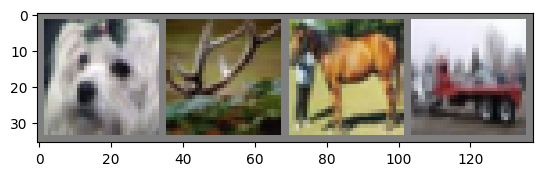

Labels: ['dog', 'deer', 'horse', 'truck']


In [33]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images))
print("Labels:", [classes[label] for label in labels])


**Build the CNN Model**

In [34]:
import torch.nn as nn
import torch.nn.functional as F

In [35]:
class SimpleCNN(nn.Module):
    def __init__(self):
      super().__init__()
      # conv1: in_channels=3 (RGB), out_channels=6, kernel_size=5
      self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
      # pool halves the spatial dims: MaxPool2d(2,2)
      self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
      # conv2: in_channels=6, out_channels=16, kernel_size=5
      self.conv2 = nn.Conv2d(6, 16, 5)



      self.fc1 = nn.Linear(16 * 5 * 5, 120)
      self.fc2 = nn.Linear(120, 84)
      self.fc3 = nn.Linear(84, 10)


    def forward(self, x):
        # x shape: [B, 3, 32, 32]
        x = F.relu(self.conv1(x))          # conv1 -> shape?
        x = self.pool(x)                   # pool -> shape?
        x = F.relu(self.conv2(x))          # conv2 -> shape?
        x = self.pool(x)                   # pool -> shape?
        # flatten:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                    # raw scores (logits)
        return x

In [36]:
net = SimpleCNN()
net

SimpleCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Loss & Optimizer (deep reasoning)

In [37]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [38]:
criterion

CrossEntropyLoss()

In [39]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

Train the Model

In [40]:
for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        inputs, labels = data


        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        # print(loss)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # print(f"Batch {i+1}, Loss: {loss.item()}")

    print(f"Epoch {epoch+1}, Loss: {running_loss}")


Epoch 1, Loss: 20968.20884643495
Epoch 2, Loss: 16707.42168752104


In [41]:
correct = 0
total = 0

with torch.no_grad():
    for data in trainloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)


Accuracy: 57.396
